# Single Asset Pipeline Demo

This notebook runs the single-asset end-to-end demo and inspects the generated factor, position, and backtest artifacts under workspace_data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
DEMO_DIR = REPO_ROOT / "demo" / "single_asset_demo"
if str(DEMO_DIR) not in sys.path:
    sys.path.insert(0, str(DEMO_DIR))

from run_single_asset_pipeline_demo import load_demo_artifacts, run_demo

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

In [2]:
summary = run_demo(force=True)
artifacts = load_demo_artifacts(summary)

summary_view = pd.DataFrame(
    [
        {"metric": "trade_days", "value": summary["inputs"]["trade_days"]},
        {"metric": "final_equity", "value": summary["backtest"]["summary"]["final_equity"]},
        {"metric": "total_return", "value": summary["backtest"]["metrics"]["total_return"]},
        {"metric": "annual_return", "value": summary["backtest"]["metrics"]["annual_return"]},
        {"metric": "sharpe", "value": summary["backtest"]["metrics"]["sharpe"]},
    ]
)
display(summary_view)
summary["paths"]

2026-04-05 19:27:37 | INFO    | factor_engine.runtime.engine | 开始从配置物化因子: /home/yluel/share/projects/quantsociety_backend_project/workspace_data/demos/single_asset_pipeline_demo/configs/factor_engine/single_asset_mom_3_v1.yaml
2026-04-05 19:27:37 | INFO    | factor_engine.runtime.engine | 加载配置文件: /home/yluel/share/projects/quantsociety_backend_project/workspace_data/demos/single_asset_pipeline_demo/configs/factor_engine/single_asset_mom_3_v1.yaml
2026-04-05 19:27:37 | INFO    | factor_engine.runtime.engine | 配置加载完成: factor=close_mom_3, backend=PandasBackend, data_source=KlineParquetSource, cache=on
2026-04-05 19:27:37 | INFO    | factor_engine.runtime.engine | 开始落盘因子 'close_mom_3'
2026-04-05 19:27:37 | INFO    | factor_engine.runtime.engine | 开始执行因子 'close_mom_3'
2026-04-05 19:27:37 | INFO    | factor_engine.runtime.engine | 开始编译因子 'close_mom_3'
2026-04-05 19:27:37 | INFO    | factor_engine.runtime.engine | 完成编译因子 'close_mom_3'，lookback=3，耗时 0.00s
2026-04-05 19:27:37 | INFO    | factor

,metric,value
0,trade_days,90.000000
1,final_equity,125728.160272
2,total_return,0.257282
3,annual_return,0.898502
4,sharpe,20.265722


{'demo_root': '/home/yluel/share/projects/quantsociety_backend_project/workspace_data/demos/single_asset_pipeline_demo',
 'configs_root': '/home/yluel/share/projects/quantsociety_backend_project/workspace_data/demos/single_asset_pipeline_demo/configs',
 'inputs_root': '/home/yluel/share/projects/quantsociety_backend_project/workspace_data/demos/single_asset_pipeline_demo/inputs',
 'reports_root': '/home/yluel/share/projects/quantsociety_backend_project/workspace_data/demos/single_asset_pipeline_demo/reports',
 'kline_root': '/home/yluel/share/projects/quantsociety_backend_project/workspace_data/demos/single_asset_pipeline_demo/inputs/day_aggs_v1',
 'market_data_path': '/home/yluel/share/projects/quantsociety_backend_project/workspace_data/demos/single_asset_pipeline_demo/inputs/mock_single_asset_ohlcv.parquet',
 'factor_lake_root': '/home/yluel/share/projects/quantsociety_backend_project/workspace_data/factors/lake',
 'alpha_output_root': '/home/yluel/share/projects/quantsociety_backen

In [3]:
factor_frame = artifacts["factor_frame"].copy()
factor_frame["timestamp"] = pd.to_datetime(factor_frame["timestamp"])
factor_frame = factor_frame.set_index("timestamp")

target_position = artifacts["target_position"].copy()
target_position["timestamp"] = pd.to_datetime(target_position["timestamp"])

returns = artifacts["returns"].copy()
returns["timestamp"] = pd.to_datetime(returns["timestamp"])

display(factor_frame.head())
display(target_position.head(12))
display(target_position["action_name"].value_counts().rename_axis("action_name").to_frame("count"))
display(returns.tail())

,mom_3,gap_5,vol_delta_2
timestamp,,,
2024-01-04,NaN,NaN,126.095001
2024-01-05,1.564404,NaN,121.875999
2024-01-08,1.692500,0.011079,115.028999
2024-01-09,1.783427,0.011618,105.829002
2024-01-10,1.843102,0.011947,94.642998


,timestamp,symbol,target_position,signal_value,action_name
0,2024-01-02,SINGLE_DEMO,0.00,0.000000,HOLD
1,2024-01-03,SINGLE_DEMO,0.00,0.000000,HOLD
2,2024-01-04,SINGLE_DEMO,0.00,0.000000,HOLD
3,2024-01-05,SINGLE_DEMO,0.00,0.000000,HOLD
4,2024-01-08,SINGLE_DEMO,0.00,0.000000,HOLD
5,2024-01-09,SINGLE_DEMO,0.00,0.000000,HOLD
6,2024-01-10,SINGLE_DEMO,0.00,0.000000,HOLD
7,2024-01-11,SINGLE_DEMO,0.00,0.000000,HOLD
8,2024-01-12,SINGLE_DEMO,0.00,0.000000,HOLD
9,2024-01-15,SINGLE_DEMO,0.00,0.000000,ENTRY_LONG


,count
action_name,
HOLD,85
ENTRY_LONG,3
EXIT_LONG,2


,timestamp,equity_curve,period_return,realized_position
85,2024-04-30,122735.357962,0.006053,0.992300
86,2024-05-01,123478.871572,0.006058,0.992346
87,2024-05-02,124227.474142,0.006063,0.992392
88,2024-05-03,124979.012722,0.006050,0.992438
89,2024-05-06,125728.160272,0.005994,0.992483


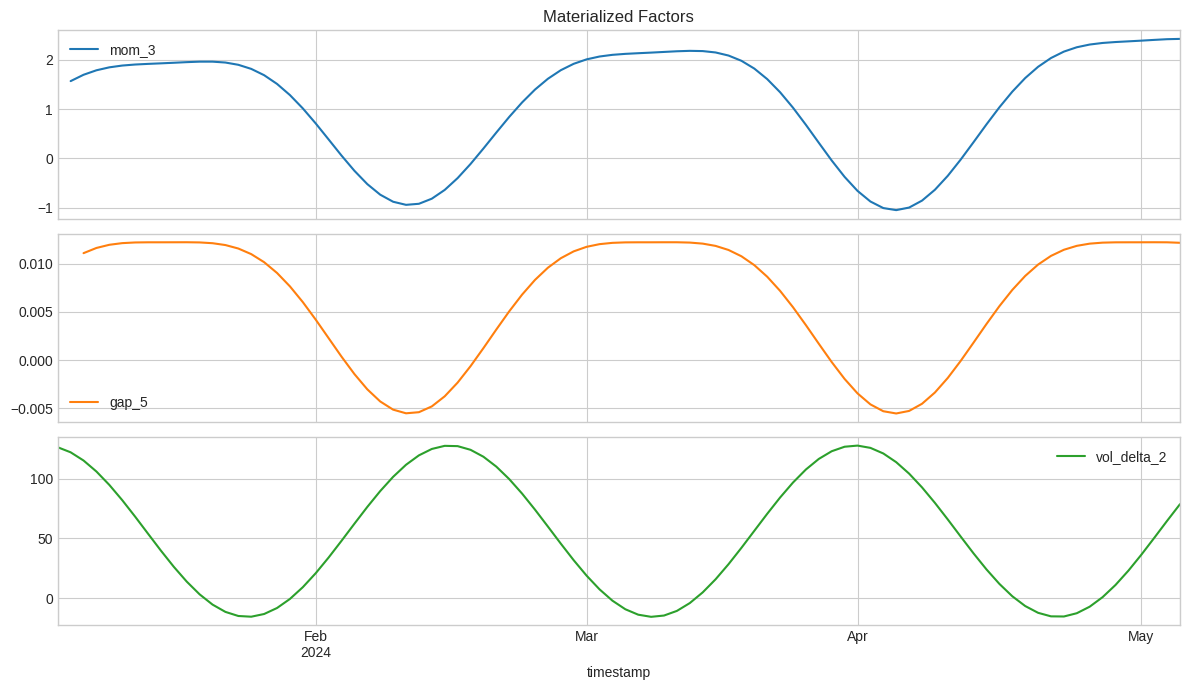

In [4]:
axes = factor_frame.plot(subplots=True, figsize=(12, 7), sharex=True)
axes[0].set_title("Materialized Factors")
plt.tight_layout()
plt.show()

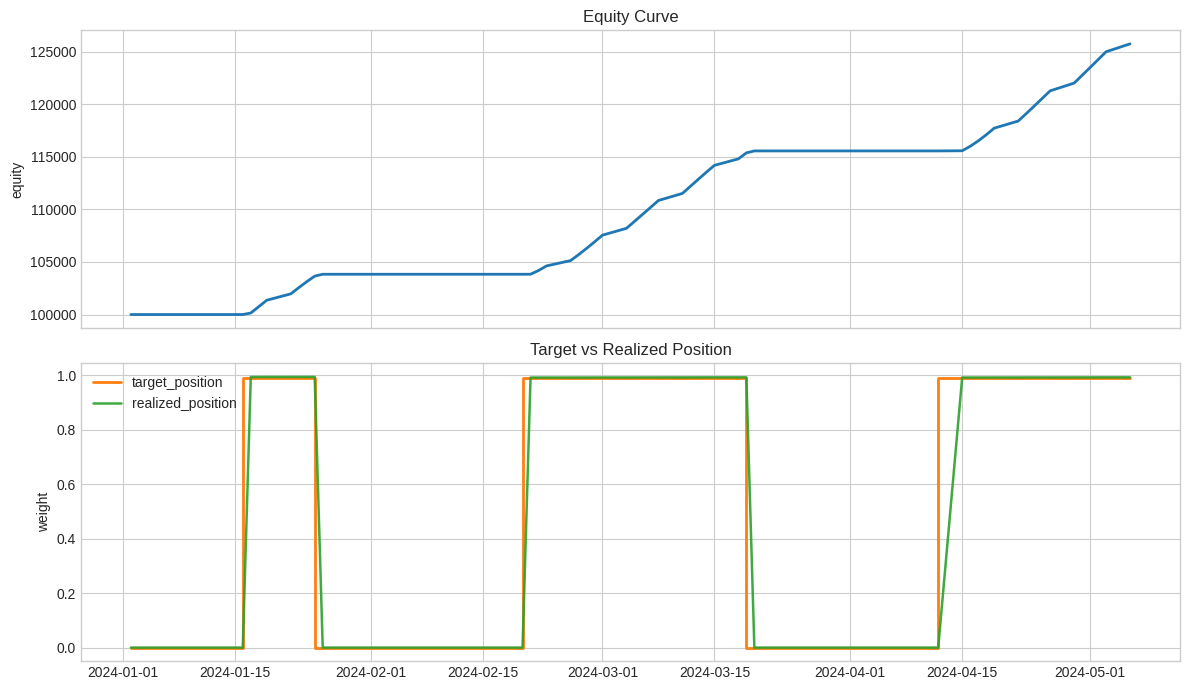

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(returns["timestamp"], returns["equity_curve"], color="#1f77b4", linewidth=2)
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("equity")

axes[1].step(
    target_position["timestamp"],
    target_position["target_position"],
    where="post",
    label="target_position",
    color="#ff7f0e",
    linewidth=2,
)
axes[1].plot(
    returns["timestamp"],
    returns["realized_position"],
    label="realized_position",
    color="#2ca02c",
    linewidth=1.8,
    alpha=0.9,
)
axes[1].set_title("Target vs Realized Position")
axes[1].set_ylabel("weight")
axes[1].legend()

plt.tight_layout()
plt.show()